### Notebook by Adrian copied from Nora's 2025_10_31subgen_figures.ipynb used to regenerate figures with new updated data


In [1]:
import os
import tifffile
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from skimage.draw import polygon
from matplotlib.collections import LineCollection
import pandas as pd
import numpy as np
import seaborn as sns
import json
from collections import defaultdict

In [2]:
def detect_fluorescence_bursts_by_group(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The number of standard deviations above the
                                   mean to be considered a significant burst.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (std_dev_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

def merge_dicts(dict1, dict2):
    merged = defaultdict(dict)
    
    for key in dict1.keys():
        if key in dict2:
            # Merge if key exists in both dictionaries
            for subkey, values in dict1[key].items():
                if subkey in dict2[key]:
                    # Combine the lists for subkey
                    merged[key][subkey] = list(set(values + dict2[key][subkey]))
                else:
                    merged[key][subkey] = values
            for subkey, values in dict2[key].items():
                if subkey not in merged[key]:
                    merged[key][subkey] = values
        else:
            merged[key] = dict1[key]
    
    for key in dict2.keys():
        if key not in merged:
            merged[key] = dict2[key]
    
    return dict(merged)

In [3]:
strain_exp_dict = {
"chpS":{"DUMM_giTG62_Glucose_012925": ["005"],
        "DUMM_alkA_chpS_111325": ["003", "005", "006", "007", "009", "010", "011"]}, "baeS":{"DUMM_giTG66_Glucose_012325": ["003"]},  
"lacZ":{"DUMM_giTG059_noKan_Glucose_031125": ["004"],
        "DUMM_giTG059_060_061125": ["008"]},
"gfcE": {"DUMM_giTG064_Glucose_022625": ["001", "015"]},
"gldA": {"DUMM_giTG69_Glucose_013025": ["007"]},
"alkA": {"DUMM_giTG068_063_061725_v2": ["000"],
        "DUMM_giTG63_giTG67_Glucose_121724_1_v2": ["006"],
        "DUMM_alkA_chpS_111325": ["017","018","022", "023"]},
"mazF": {"DUMM_giTG059_060_061125": ["015"]}, 
"hupA":{"DUMM_giTG068_052925": ["005"], 
        "DUMM_giTG068_063_061725": ["012"]},
"araB": {"DUMM_CL008_giTG061_081225": ["015", "016", "017", "018", "019", "020"]},
}

strain_exp_dict_2 = {
  "chpS": {
    "DUMM_giTG062_064_121325": ["005", "010", "012"]
  },
  "baeS": {
    "DUMM_gitg068_baeS_100225": ["013", "017", "018", "019", "020", "021", "022", "023"],
    "DUMM_baeS_gfcE_112025": ["005"],
    "DUMM_giTG066_063_120925": ["002", "007"]
  },
  "gfcE": {
    "DUMM_baeS_gfcE_112025": ["011", "012", "016"],
    "DUMM_giTG062_064_121325": ["015", "019"],
    "DUMM_giTG060_064_121425": ["013", "014", "020", "022"]
  },
  "gldA": {
    "DUMM_giTG069_063_121125": ["013", "016", "022", "025"],
    "DUMM_giTG069_063_121225": ["013", "018", "022"]
  },
  "alkA": {
    "DUMM_giTG066_063_120925": ["018", "019"],
    "DUMM_giTG069_063_121125": ["001", "005", "006", "008"],
    "DUMM_giTG069_063_121225": ["000"]
  },
  "mazF": {
    "DUMM_giTG060_064_121425": ["000", "005"],
    "DUMM_mazF_murQ_121625": ["005", "006", "012"]
  },
  "murQ": {
    "DUMM_mazF_murQ_121625": ["017", "018"]
  }
}

strain_exp_dict_3={
"lacZ":{"DUMM_giTG059_068_SC_093025": ["015", "020"]
    },
"araB": {"CL008_giTG068_072925": ["003", "007", "009"]
    }
}

minutes_interval = {"DUMM_giTG62_Glucose_012925":5,
"DUMM_giTG66_Glucose_012325":5,
"DUMM_giTG059_noKan_Glucose_031125":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG064_Glucose_022625":5,
"DUMM_giTG69_Glucose_013025":5,
"DUMM_giTG068_063_061725_v2":10,
"DUMM_giTG63_giTG67_Glucose_121724_1_v2":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG068_052925":5,
"DUMM_giTG068_063_061725":10,
"DUMM_CL008_giTG061_081225":10,
"DUMM_alkA_chpS_111325":10,
"DUMM_giTG062_064_121325":10,
"DUMM_gitg068_baeS_100225":10,
"DUMM_baeS_gfcE_112025":10,
"DUMM_giTG066_063_120925":10,
"DUMM_giTG060_064_121425":10,
"DUMM_giTG069_063_121125":10,
"DUMM_giTG069_063_121225":10,
"DUMM_mazF_murQ_121625":10,
"DUMM_giTG059_068_SC_093025":10,
"CL008_giTG068_072925":10
}

combined_dict1 = merge_dicts(strain_exp_dict, strain_exp_dict_2)
combined_dict = merge_dicts(combined_dict1, strain_exp_dict_3)



In [4]:
#load data files together 
tracked_all_cells_filename1 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/20250829_tracked_all_cell_data.pkl'
tracked_all_cells_filename2 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/tracked_all_cell_data031625.pkl'
tracked_all_cells_filename3 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/tracked_all_cell_data_120125.pkl'
tracked_all_cells_filename4 = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/tracked_all_cell_data_032026.pkl'

# Read in the DataFrames
df1 = pd.read_pickle(tracked_all_cells_filename1)
df2 = pd.read_pickle(tracked_all_cells_filename2)
df3 = pd.read_pickle(tracked_all_cells_filename3)
df4 = pd.read_pickle(tracked_all_cells_filename4)

df1['unique_node_id'] = 'df1_' + df1['node_id'].astype(str)
df2['unique_node_id'] = 'df2_' + df2['node_id'].astype(str)
df3['unique_node_id'] = 'df3_' + df3['node_id'].astype(str)
df4['unique_node_id'] = 'df4_' + df4['node_id'].astype(str)

all_lineages_df = pd.concat([df1, df2, df3, df4], axis=0, ignore_index=True)
all_lineages_temp = all_lineages_df.copy()


In [5]:
exposure_dict= {'CL008_giTG068_072925': [45, 150],
'DUMM_alkA_chpS_111325': [120, 150],
'DUMM_baeS_gfcE_112025': [120, 150],
'DUMM_CL008_giTG061_081225': [120, 150],
'DUMM_giTG059_060_061125': [250, 250],
'DUMM_giTG059_068_SC_093025': [120, 150],
'DUMM_giTG059_noKan_Glucose_031125': [250, 450],
'DUMM_giTG060_064_121425': [120, 150],
'DUMM_giTG062_064_121325': [120, 150],
'DUMM_giTG064_Glucose_022625': [250, 500],
'DUMM_giTG066_063_120925': [120, 150],
'DUMM_giTG068_052925': [250, 450],
'DUMM_giTG068_063_061725': [45, 150],
'DUMM_gitg068_baeS_100225': [120, 150],
'DUMM_giTG069_063_121125': [120, 150],
'DUMM_giTG069_063_121225': [120, 150],
'DUMM_giTG66_Glucose_012325': [250, 500],
'DUMM_giTG69_Glucose_013025': [250, 500],
'DUMM_mazF_murQ_121625': [120, 150],
'DUMM_giTG068_063_061725_v2': [45, 150],
'DUMM_giTG63_giTG67_Glucose_121724_1_v2': [250, 500],
'DUMM_giTG62_Glucose_012925': [250, 500]
}

### used to plot mean phase/fluor of different experiments
 

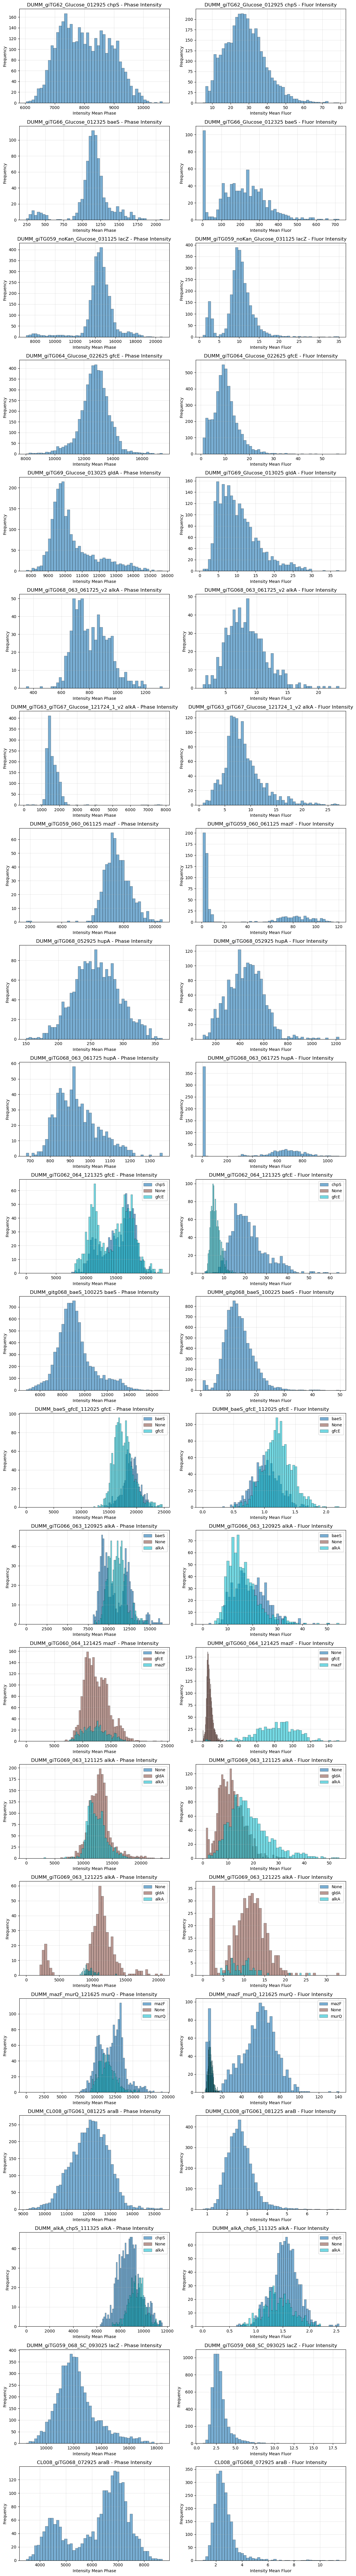

In [6]:

# Get unique experiments
experiments = all_lineages_temp['experiment_name'].unique()

# Create subplots - 2 columns (one for each intensity type)
n_experiments = len(experiments)
fig, axes = plt.subplots(n_experiments, 2, figsize=(12, 4*n_experiments))

# Handle case where there's only one experiment
if n_experiments == 1:
    axes = axes.reshape(1, -1)

for idx, experiment in enumerate(experiments):
    # Filter data for this experiment and remove None genes
    exp_data = all_lineages_temp[all_lineages_temp['experiment_name'] == experiment]
    # exp_data = exp_data[exp_data['gene'].notna() & (exp_data['gene'] != 'none') & (exp_data['gene'] != 'None')]
    
    # Get unique genes for this experiment
    genes = exp_data['gene'].unique()
    
    # Define colors for different genes
    colors = plt.cm.tab10(np.linspace(0, 1, len(genes)))
    
    # Plot intensity_mean_phase
    for gene_idx, gene in enumerate(genes):
        gene_data = exp_data[exp_data['gene'] == gene]
        axes[idx, 0].hist(gene_data['intensity_mean_phase'].dropna(), bins=50, 
                          color=colors[gene_idx], alpha=0.6, 
                          label=f'{gene}', edgecolor='black', linewidth=0.5)
    
    axes[idx, 0].set_xlabel('Intensity Mean Phase')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{experiment} {gene} - Phase Intensity')
    axes[idx, 0].grid(True, alpha=0.3)
    if len(genes) > 1:
        axes[idx, 0].legend()
    
    # Plot intensity_mean_fluor
    for gene_idx, gene in enumerate(genes):
        gene_data = exp_data[exp_data['gene'] == gene]
        axes[idx, 1].hist(gene_data['intensity_mean_fluor'].dropna(), bins=50, 
                          color=colors[gene_idx], alpha=0.6, 
                          label=f'{gene}', edgecolor='black', linewidth=0.5)
    
    axes[idx, 1].set_xlabel('Intensity Mean Fluor')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{experiment} {gene} - Fluor Intensity')
    axes[idx, 1].grid(True, alpha=0.3)
    if len(genes) > 1:
        axes[idx, 1].legend()

plt.tight_layout()
plt.show()

### the following plots histograms for phase/fluor for each gene with each experiment per gene 

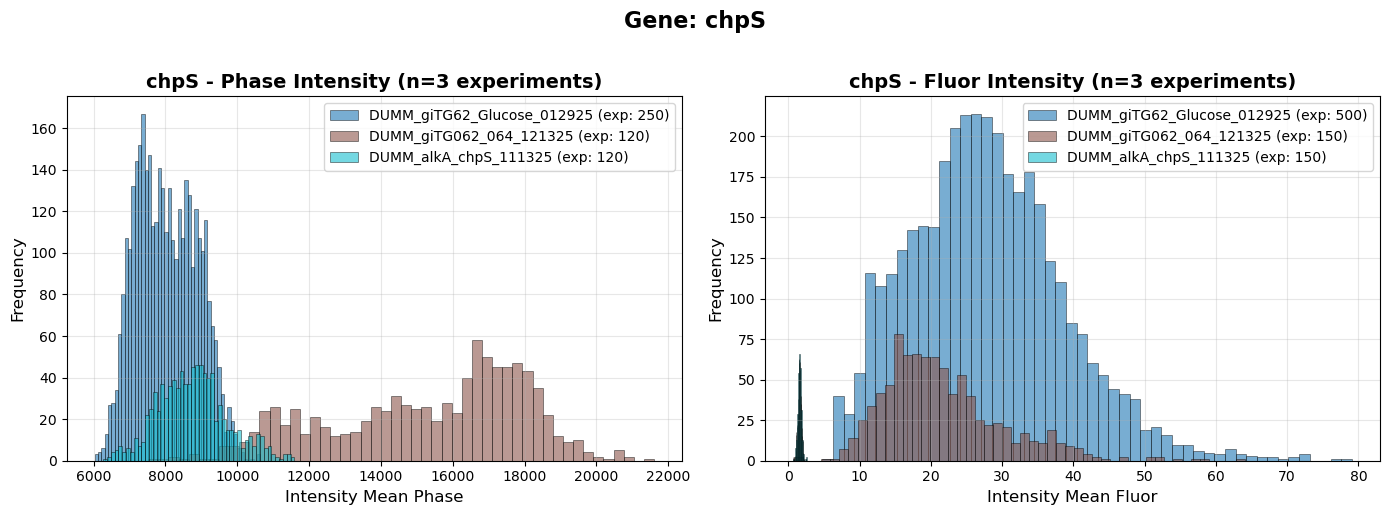

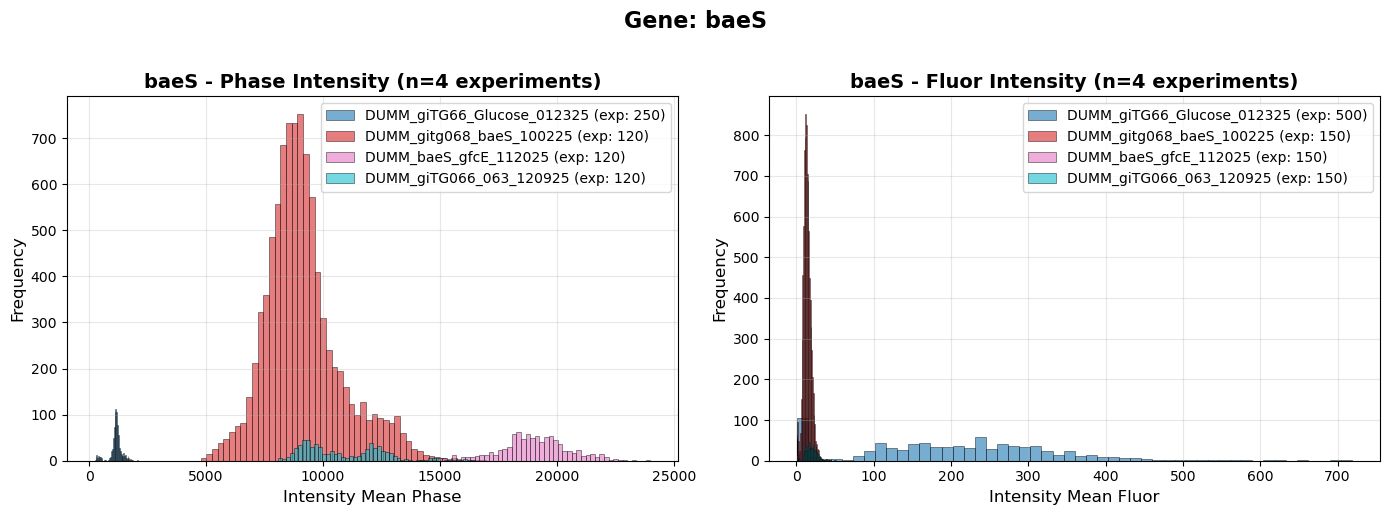

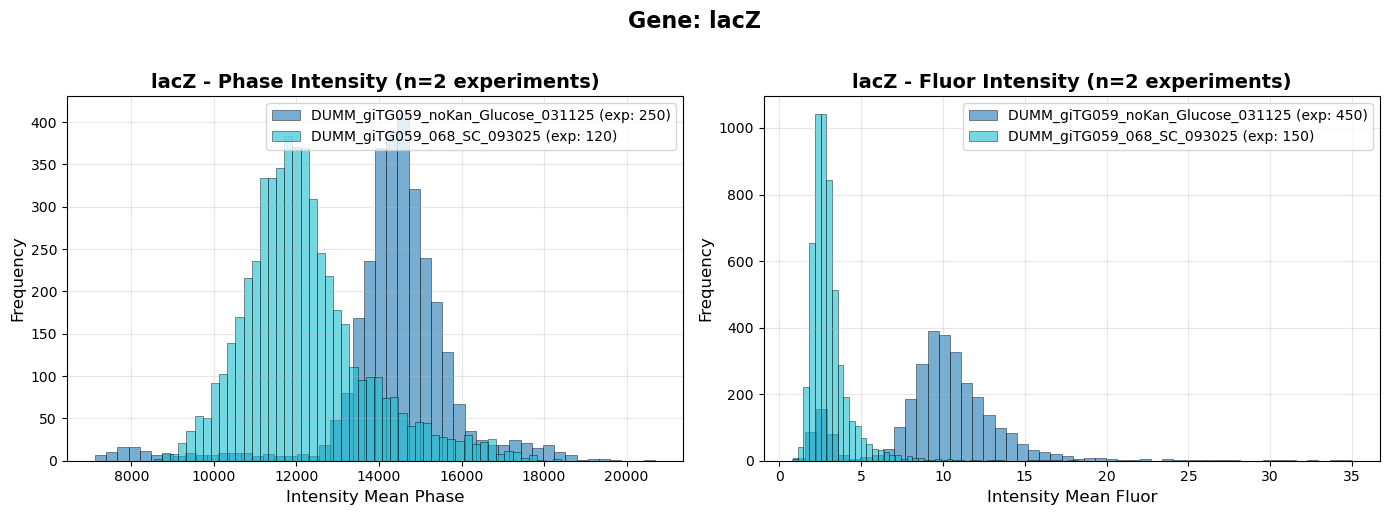

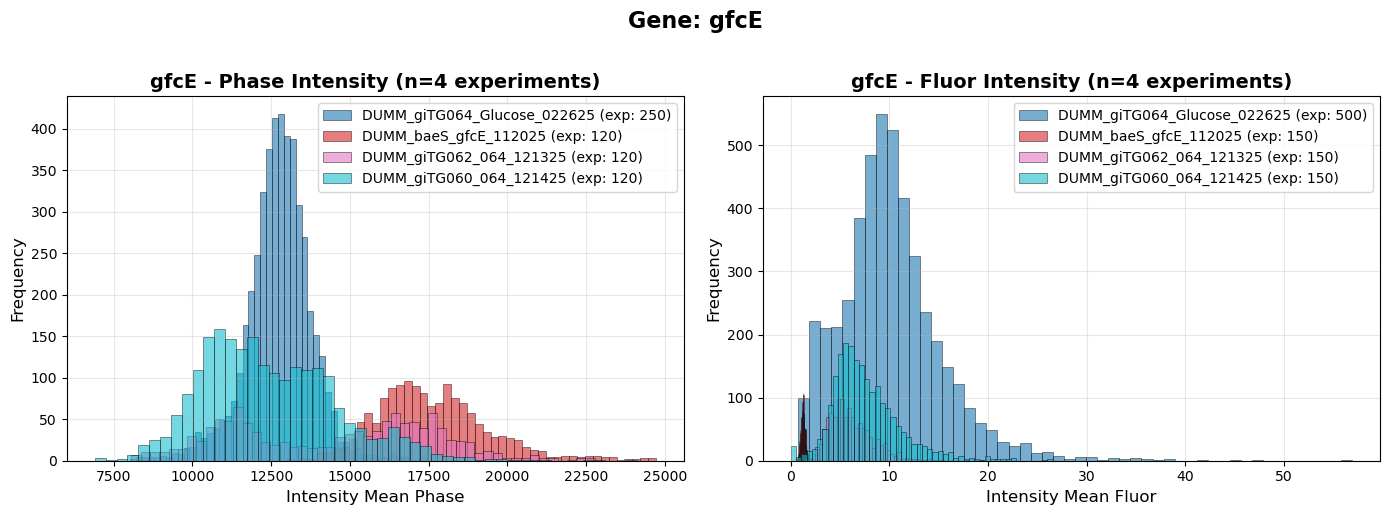

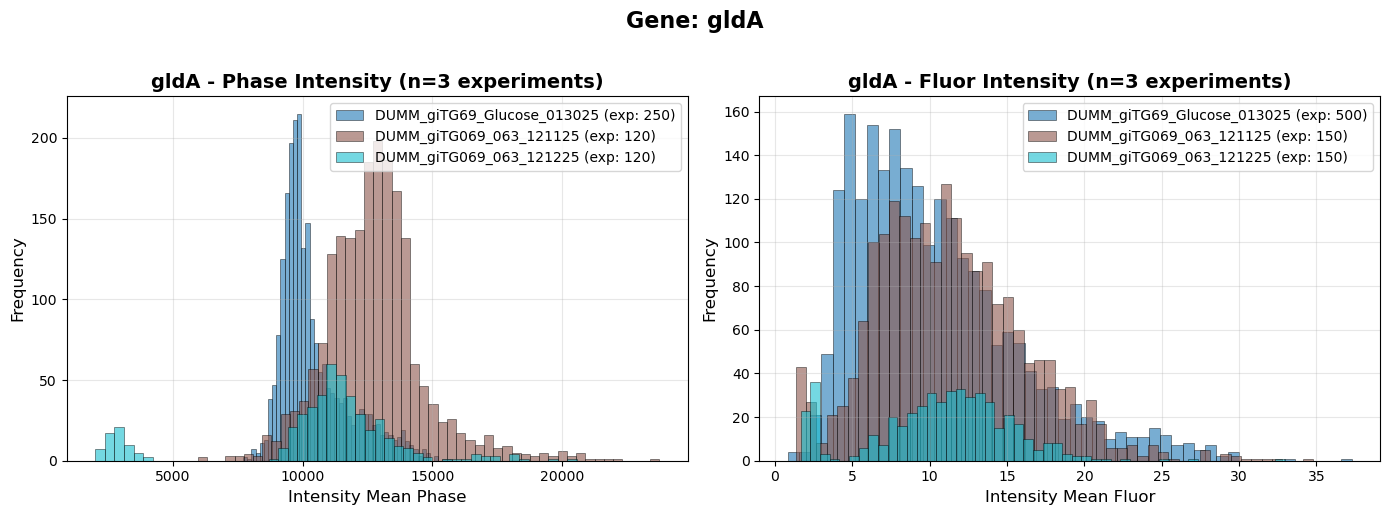

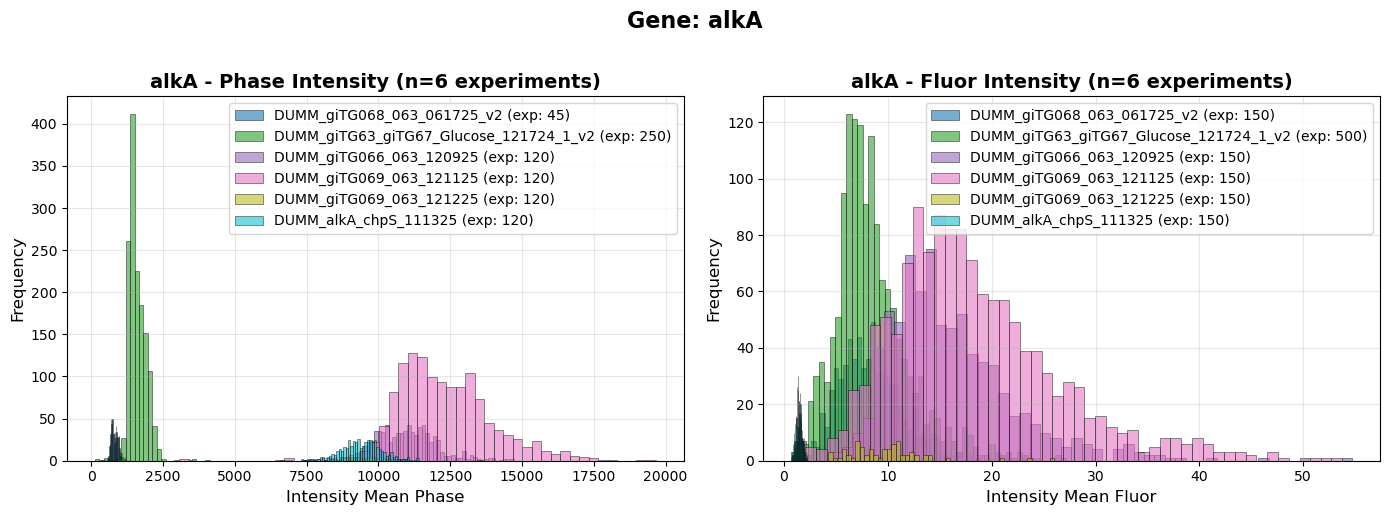

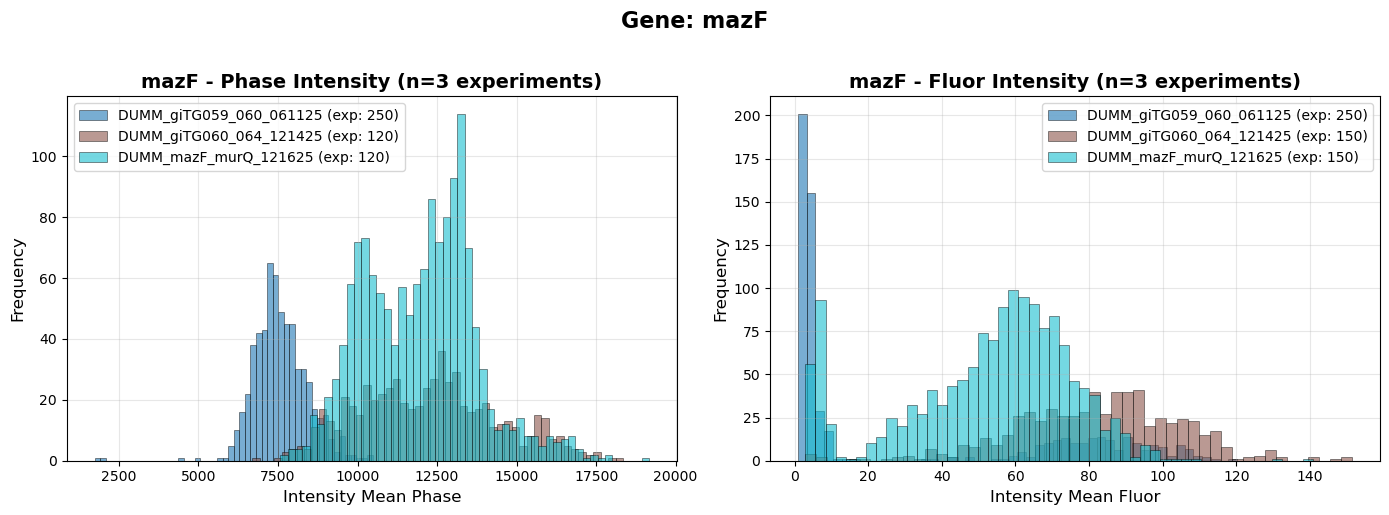

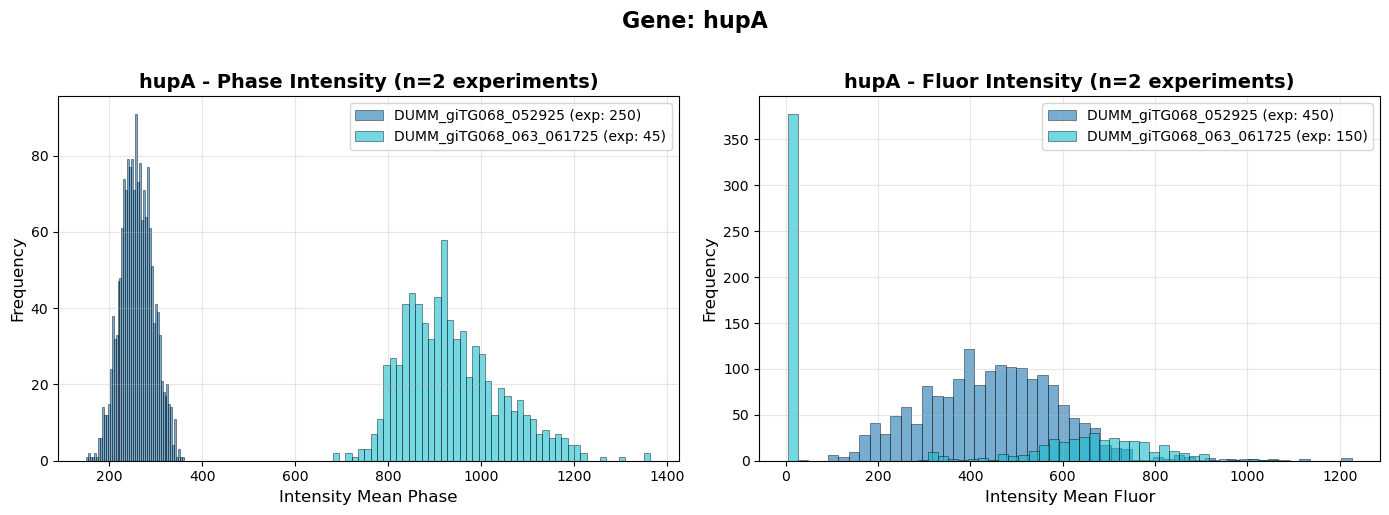

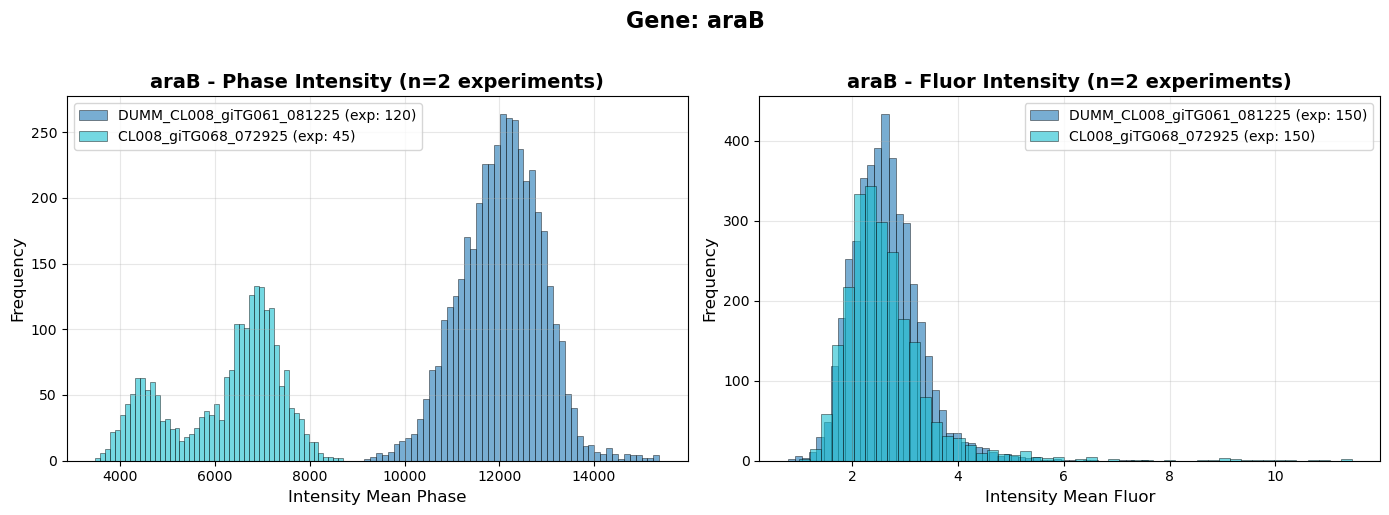

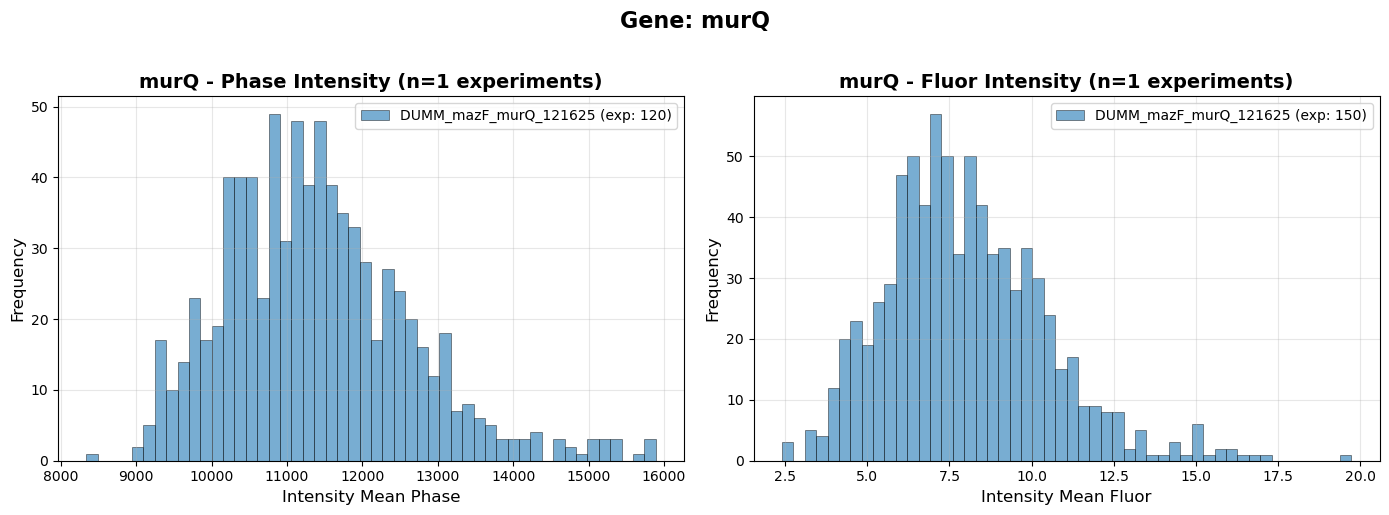

In [7]:
import matplotlib.pyplot as plt
import numpy as np

genes = ['chpS', 'baeS', 'lacZ', 'gfcE', 'gldA', 'alkA', 'mazF', 'hupA', 'araB', 'murQ']

filtered_df = all_lineages_df[
    all_lineages_df['gene'].notna() & 
    (all_lineages_df['gene'].astype(str).str.lower() != 'none')
]

for gene in genes:
    gene_data = filtered_df[filtered_df['gene'] == gene]
    
    if len(gene_data) == 0:
        print(f"No data for gene: {gene}")
        continue
    
    experiments = gene_data['experiment_name'].unique()
    n_experiments = len(experiments)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, n_experiments))
    
    # Plot intensity_mean_phase
    for exp_idx, experiment in enumerate(experiments):
        exp_data = gene_data[gene_data['experiment_name'] == experiment]
        
        # Get exposure info
        if experiment in exposure_dict:
            phase_exp = exposure_dict[experiment][0]
            label = f'{experiment} (exp: {phase_exp})'
        else:
            label = f'{experiment} (exp: N/A)'
        
        axes[0].hist(exp_data['intensity_mean_phase'].dropna(), bins=50, 
                     color=colors[exp_idx], alpha=0.6, 
                     label=label, edgecolor='black', linewidth=0.5)
    
    axes[0].set_xlabel('Intensity Mean Phase', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title(f'{gene} - Phase Intensity (n={n_experiments} experiments)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot intensity_mean_fluor
    for exp_idx, experiment in enumerate(experiments):
        exp_data = gene_data[gene_data['experiment_name'] == experiment]
        
        # Get exposure info
        if experiment in exposure_dict:
            fluor_exp = exposure_dict[experiment][1]
            label = f'{experiment} (exp: {fluor_exp})'
        else:
            label = f'{experiment} (exp: N/A)'
        
        axes[1].hist(exp_data['intensity_mean_fluor'].dropna(), bins=50, 
                     color=colors[exp_idx], alpha=0.6, 
                     label=label, edgecolor='black', linewidth=0.5)
    
    axes[1].set_xlabel('Intensity Mean Fluor', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title(f'{gene} - Fluor Intensity (n={n_experiments} experiments)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.suptitle(f'Gene: {gene}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [8]:
def detect_fluorescence_bursts_by_group_temp(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2,
    exposure_dict: dict = None,
    exposure_threshold_map: dict = None
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        fluor_col (str): Column name for fluorescence intensity.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The default number of standard deviations above the
                                   mean to be considered a significant burst.
        exposure_dict (dict): Dictionary mapping experiment names to [phase_exposure, fluor_exposure].
        exposure_threshold_map (dict): Dictionary mapping fluorescence exposure values to 
                                       std_dev_threshold values. If None, uses default mapping.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    # Default exposure-to-threshold mapping if not provided
    if exposure_threshold_map is None:
        exposure_threshold_map = {
            150: 2.5,
            250: 3.0,
            450: 3.5,
            500: 4.0
        }
    
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')
        
        # Determine the std_dev_threshold for this experiment
        experiment_name = name[1]  # Extract experiment_name from groupby tuple
        current_threshold = std_dev_threshold  # Default threshold
        
        if exposure_dict is not None and experiment_name in exposure_dict:
            fluor_exposure = exposure_dict[experiment_name][1]  # Get fluorescence exposure
            
            # Map exposure to threshold
            if fluor_exposure in exposure_threshold_map:
                current_threshold = exposure_threshold_map[fluor_exposure]
            else:
                # Find closest exposure value if exact match not found
                closest_exposure = min(exposure_threshold_map.keys(), 
                                     key=lambda x: abs(x - fluor_exposure))
                current_threshold = exposure_threshold_map[closest_exposure]

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding (using exposure-adjusted threshold)
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (current_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)
        
        # Optional: Add a column to track which threshold was used
        group['std_dev_threshold_used'] = current_threshold

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

In [9]:
### original code:
all_lineages_temp['gene'] = None

# for each experiment this
for gene, exps_fov in combined_dict.items():
    for exp_view, fovs in exps_fov.items():
        mask = all_lineages_temp['FOV'].isin(fovs) & (all_lineages_temp['experiment_name'] == exp_view)
        all_lineages_temp.loc[mask, 'gene'] = gene
        
bursts_all_lineages_df = detect_fluorescence_bursts_by_group(all_lineages_temp,
                                                            fluor_col = 'intensity_mean_fluor',
                                                            rolling_window_size = 10,
                                                            std_dev_threshold = 3,
                                                            )

counts_per_lineage = bursts_all_lineages_df.groupby(['gene', 'experiment_name', 'FOV', 'trench_id']).size()

time_frames_per_avg_cell_cycle = counts_per_lineage.groupby(['gene', 'experiment_name']).mean().reset_index().rename(columns={0: 'average_frame_count'})
# First, calculate the number of peaks and unique cells for each gene/experiment combo.
grouped_data = bursts_all_lineages_df.groupby(['gene', 'experiment_name']).agg(
    num_peaks=('is_burst', 'sum'),  # Summing boolean 'is_burst' counts the True values
    num_cell_images=('unique_node_id', pd.Series.nunique)
).reset_index()

# Second, merge this with the cell cycle length data
peak_freq_df = pd.merge(grouped_data, time_frames_per_avg_cell_cycle,
                        on=['gene', 'experiment_name'])
# Third, perform the final calculation
peak_freq_df['peak_frequency'] = (peak_freq_df['num_peaks'] / peak_freq_df['num_cell_images']) * peak_freq_df['average_frame_count']
avg_peak_freq_per_gene = peak_freq_df.groupby('gene')['peak_frequency'].mean().reset_index()


In [10]:
all_lineages_temp['gene'] = None

# for each experiment this
for gene, exps_fov in combined_dict.items():
    for exp_view, fovs in exps_fov.items():
        mask = all_lineages_temp['FOV'].isin(fovs) & (all_lineages_temp['experiment_name'] == exp_view)
        all_lineages_temp.loc[mask, 'gene'] = gene
        
bursts_all_lineages_df = detect_fluorescence_bursts_by_group_temp(all_lineages_temp,
                                                            fluor_col = 'intensity_mean_fluor',
                                                            rolling_window_size = 10,
                                                            std_dev_threshold = 3,
                                                            exposure_dict = exposure_dict)

counts_per_lineage = bursts_all_lineages_df.groupby(['gene', 'experiment_name', 'FOV', 'trench_id']).size()

time_frames_per_avg_cell_cycle = counts_per_lineage.groupby(['gene', 'experiment_name']).mean().reset_index().rename(columns={0: 'average_frame_count'})
# First, calculate the number of peaks and unique cells for each gene/experiment combo.
grouped_data = bursts_all_lineages_df.groupby(['gene', 'experiment_name']).agg(
    num_peaks=('is_burst', 'sum'),  # Summing boolean 'is_burst' counts the True values
    num_cell_images=('unique_node_id', pd.Series.nunique)
).reset_index()

# Second, merge this with the cell cycle length data
peak_freq_df = pd.merge(grouped_data, time_frames_per_avg_cell_cycle,
                        on=['gene', 'experiment_name'])
# Third, perform the final calculation
peak_freq_df['peak_frequency'] = (peak_freq_df['num_peaks'] / peak_freq_df['num_cell_images']) * peak_freq_df['average_frame_count']
avg_peak_freq_per_gene = peak_freq_df.groupby('gene')['peak_frequency'].mean().reset_index()

In [11]:
cols_use = ['gene', 'experiment_name', 'FOV', 'trench_id', 'predicted_lineage']
bursts_all_lineages_df['subgen'] = bursts_all_lineages_df.groupby(cols_use)['is_burst'].transform('any')

In [12]:
for gene in bursts_all_lineages_df['gene'].unique():
    print(gene)
    print(bursts_all_lineages_df['intensity_max_fluor'][bursts_all_lineages_df['gene'] == gene].describe())

alkA
count    5268.000000
mean       35.629082
std        16.712225
min         5.000000
25%        28.000000
50%        36.000000
75%        44.000000
max       114.000000
Name: intensity_max_fluor, dtype: float64
araB
count    6641.000000
mean       13.803041
std         3.254382
min         6.000000
25%        12.000000
50%        13.000000
75%        15.000000
max        42.000000
Name: intensity_max_fluor, dtype: float64
baeS
count    13197.000000
mean        47.716301
std         81.796165
min          3.000000
25%         25.000000
50%         32.000000
75%         39.000000
max        994.000000
Name: intensity_max_fluor, dtype: float64
chpS
count    7360.000000
mean       38.190083
std        19.963835
min         5.000000
25%        16.000000
50%        40.000000
75%        51.000000
max       128.000000
Name: intensity_max_fluor, dtype: float64
gfcE
count    14374.000000
mean        21.805344
std          9.229409
min          0.000000
25%         16.000000
50%         23.00

In [13]:
mask_baseline_exp = (bursts_all_lineages_df['intensity_max_fluor']> 60) & (~bursts_all_lineages_df['subgen'])
bursts_all_lineages_df['subgen'][mask_baseline_exp] = True

/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_367/4147307789.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bursts_all_lineages_df['subgen'][mask_baseline_exp] = True
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykern

In [14]:
bursts_all_lineages_df['time_interval_minutes'] = bursts_all_lineages_df['experiment_name'].map(minutes_interval)
bursts_all_lineages_df['time_minutes'] = bursts_all_lineages_df['time_interval_minutes'] * bursts_all_lineages_df['time_frame']

In [15]:
cols_use = ['gene', 'experiment_name', 'FOV', 'trench_id', 'predicted_lineage']
idx = bursts_all_lineages_df.groupby(cols_use)['time_minutes'].idxmin()

In [16]:
cell_first_appearance_df = bursts_all_lineages_df.loc[idx]
cell_first_appearance_df['mother_ids'] = cell_first_appearance_df['predicted_lineage'].str.split('.').str[0]

In [17]:
cells_sorted = cell_first_appearance_df.sort_values(
    by=['gene', 'experiment_name', 'FOV', 'trench_id', 'mother_ids', 'time_minutes'],
    ascending=True
).reset_index(drop=True)

In [18]:
cells_sorted.groupby('gene').count().iloc[:, 0]

gene
alkA    4664
araB    3356
baeS    6728
chpS    4030
gfcE    9680
gldA    4954
hupA     737
lacZ    2812
mazF    3895
murQ    1388
Name: label, dtype: int64

In [19]:
def calculate_gaps_exp_experimental(df: pd.DataFrame) -> dict:
    """
    Calculates the length of consecutive runs of 'subgen' == False (non-expression)
    that are bounded by 'subgen' == True (expression) cells, allowing gaps
    that start at the first cell or end at the last cell of the gene's sequence.

    Args:
        df (pd.DataFrame): DataFrame with 'gene', 'subgen' columns.
                           Rows are expected to be ordered chronologically.

    Returns:
        dict: A dictionary where keys are gene names and values are lists of
              the lengths (in cells/rows) of the non-expression gaps found.
    """
    gene_non_expression_gaps = {}

    if df.empty:
        return {}

    grouped = df.groupby('gene')

    for gene, gene_df in grouped:
        # Get the first and last index of the current gene's sequence
        first_index = gene_df.index[0]
        last_index = gene_df.index[-1]

        # Invert 'subgen' to treat non-expression (False) as True for RLE grouping
        is_non_expression = (gene_df['subgen'] == False)

        # 1. Identify where a run of non-expression starts
        run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))

        # 2. Assign a unique ID to each consecutive run and calculate run lengths
        run_id = run_starts.cumsum()
        non_expression_groups = run_id[is_non_expression]

        if not non_expression_groups.empty:
            non_expression_groups.name = 'run_id'
            gap_lengths_df = non_expression_groups.groupby(non_expression_groups).size().reset_index(name='length')

            # 3. Get the start and end index of each run
            run_start_indices = non_expression_groups.index.to_series().groupby(non_expression_groups).first()
            run_end_indices = non_expression_groups.index.to_series().groupby(non_expression_groups).last()

            gap_lengths_df['start_index'] = gap_lengths_df['run_id'].map(run_start_indices)
            gap_lengths_df['end_index'] = gap_lengths_df['run_id'].map(run_end_indices)

            # 4. Apply the fully inclusive boundary conditions:

            # Condition A (Precursor Check): Preceded by Expression OR Starts at First Index
            preceded_by_exp = (gene_df['subgen'].shift(1).loc[gap_lengths_df['start_index']] == True).fillna(False).values
            starts_at_first = (gap_lengths_df['start_index'] == first_index).values
            preceded_ok = preceded_by_exp | starts_at_first

            # Condition B (Successor Check): Followed by Expression OR Ends at Last Index
            followed_by_exp = (gene_df['subgen'].shift(-1).loc[gap_lengths_df['end_index']] == True).fillna(False).values
            ends_at_last = (gap_lengths_df['end_index'] == last_index).values
            followed_ok = followed_by_exp | ends_at_last

            # 5. Final Valid Gaps: (Preceded OK) AND (Followed OK)
            valid_gaps = gap_lengths_df[preceded_ok & followed_ok]

            gene_non_expression_gaps[gene] = valid_gaps['length'].tolist()
        else:
            gene_non_expression_gaps[gene] = []

    return gene_non_expression_gaps

In [20]:
results = calculate_gaps_exp_experimental(cells_sorted)

/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_367/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_367/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  run_starts = is_non_expression & (~is_non_expression.shift(1).fillna(False))
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_367/1512737563.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfi

In [21]:
def plot_average_gaps(protein_gaps_dict):
    """Calculates and plots the average gap lengths."""
    average_gaps = {}
    for protein, gaps in protein_gaps_dict.items():
        average = np.mean(gaps) if gaps else 0.0
        average_gaps[protein] = average

    df_avg = pd.DataFrame.from_dict(
        average_gaps, 
        orient='index', 
        columns=['Average Gap Length']
    ).sort_values(by='Average Gap Length', ascending=False)
    custom_order = ['lacZ', 'gldA', 'araB', 'murQ', 'alkA', 'gfcE', 'chpS', 'baeS', 'mazF', 'hupA']

    df_avg_ordered = df_avg.reindex(custom_order)

    plt.figure(figsize=(6, 6))
    bars = plt.bar(
        df_avg.index, 
        df_avg['Average Gap Length'],
        color='slateblue' 
    )

    plt.xlabel('Gene', fontsize=20)
    plt.ylabel('Average gap in expression \n (# generations)', fontsize=20)
    plt.xticks(rotation=45, fontsize=20)
    plt.yticks(fontsize=20)
    ax = plt.gca() 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

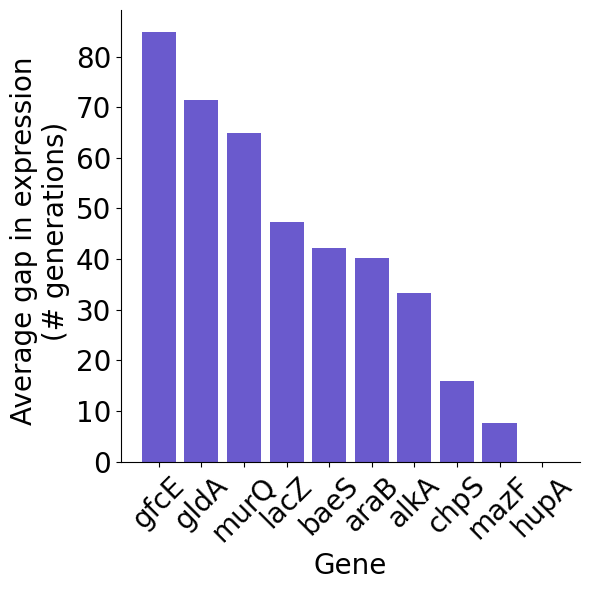

In [22]:
plot_average_gaps(results)

In [23]:
def plot_gapExperssion_stats(results, bins=30):
    """
    Create individual histogram plots for each gene.
    """
    for gene, values in results.items():
        mean_val = np.mean(values)
        var_val = np.var(values)
        std_val = np.std(values)
        
        plt.figure(figsize=(8, 6))
        
        n, bins_edges, patches = plt.hist(values, bins=bins, alpha=0.7, 
                                          color='skyblue', edgecolor='black', 
                                          density=False)
        
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_val:.3f}')
        
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', 
                   linewidth=1.5, label=f'+1 Std')
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', 
                   linewidth=1.5, label=f'-1 Std')
        
        plt.title(f'Distribution of {gene}', fontsize=14, fontweight='bold')
        plt.xlabel('Value', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        
        # Statistics text box
        textstr = f'Mean: {mean_val:.3f}\nVariance: {var_val:.3f}\nStd Dev: {std_val:.3f}\nN: {len(values)}'
        plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=11)
        
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

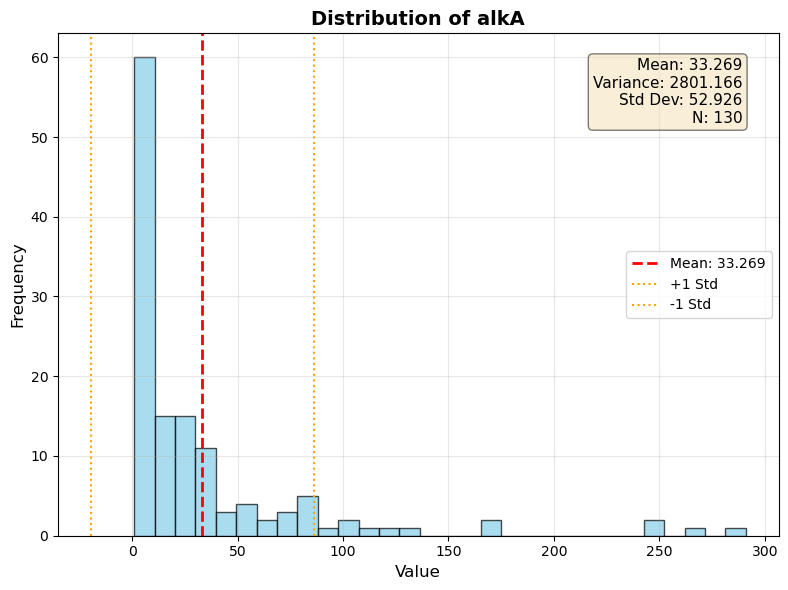

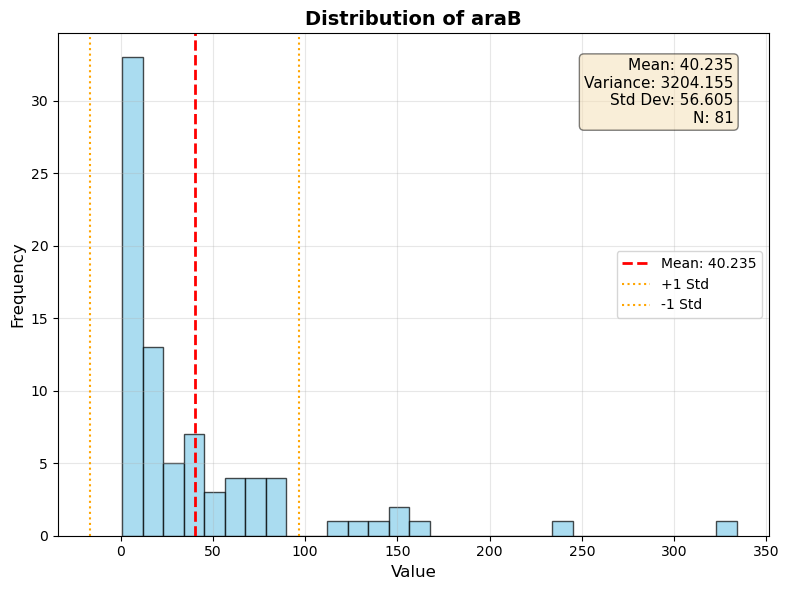

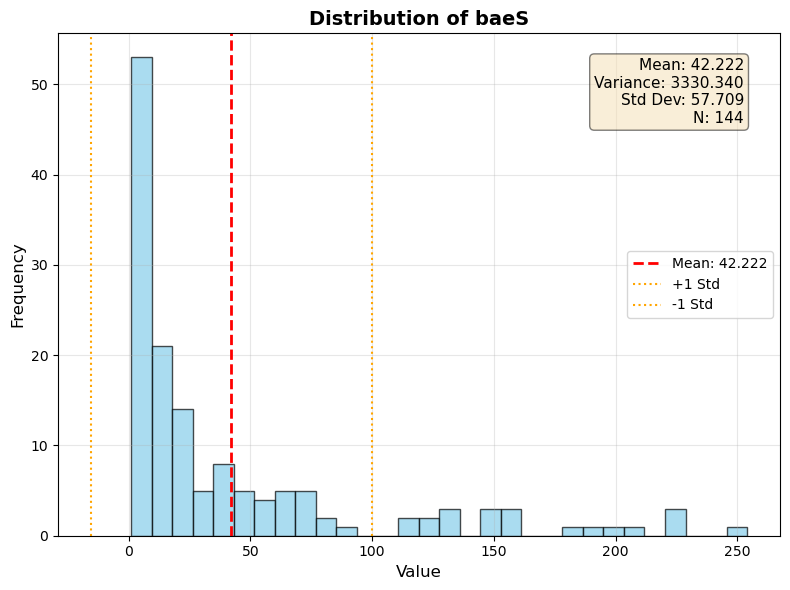

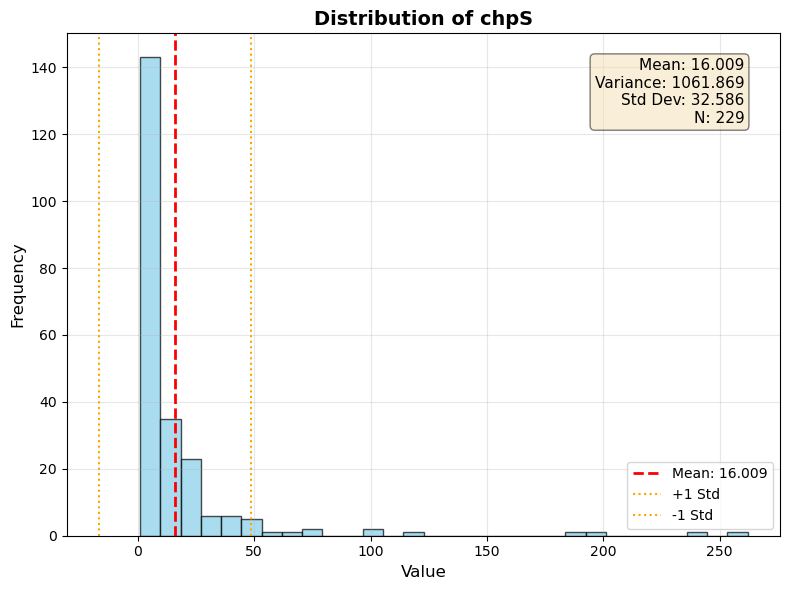

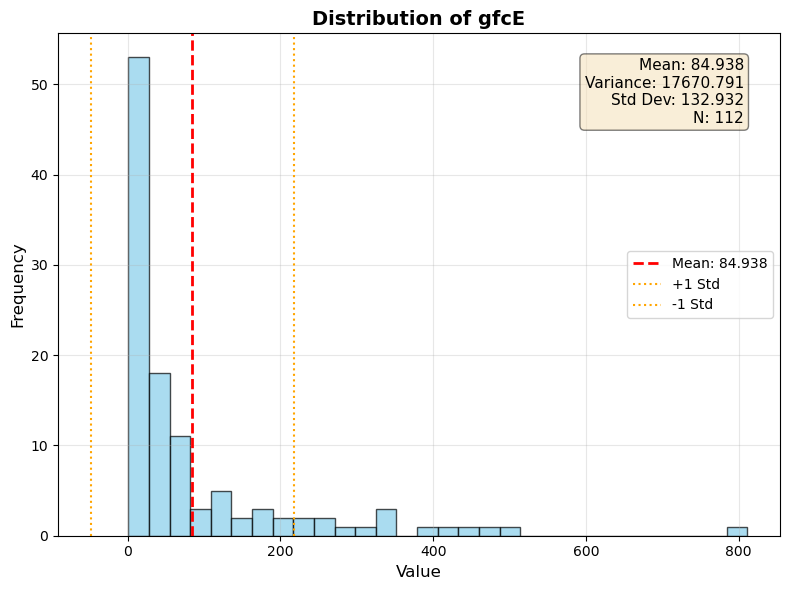

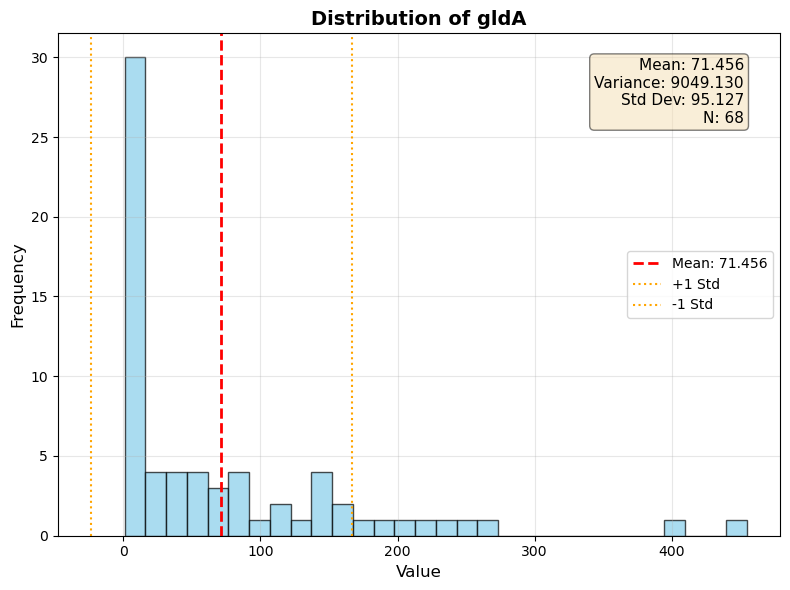

/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/numpy/_core

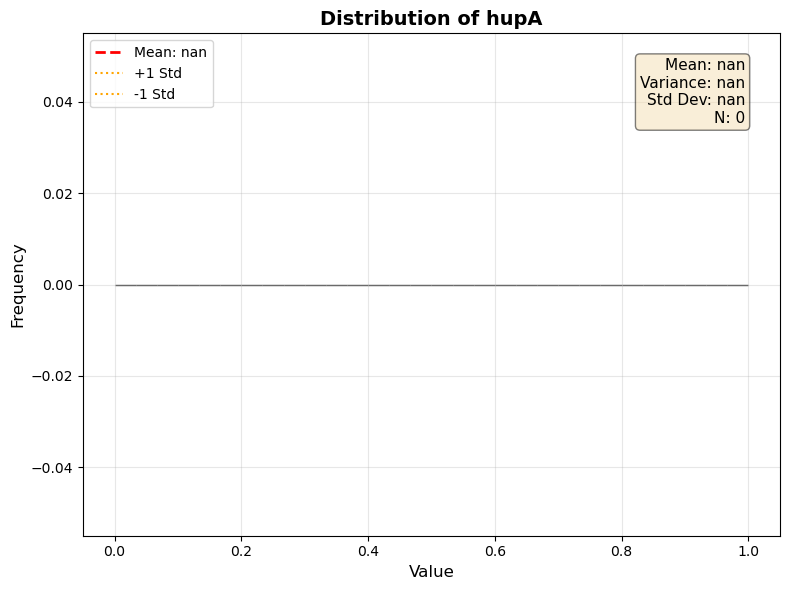

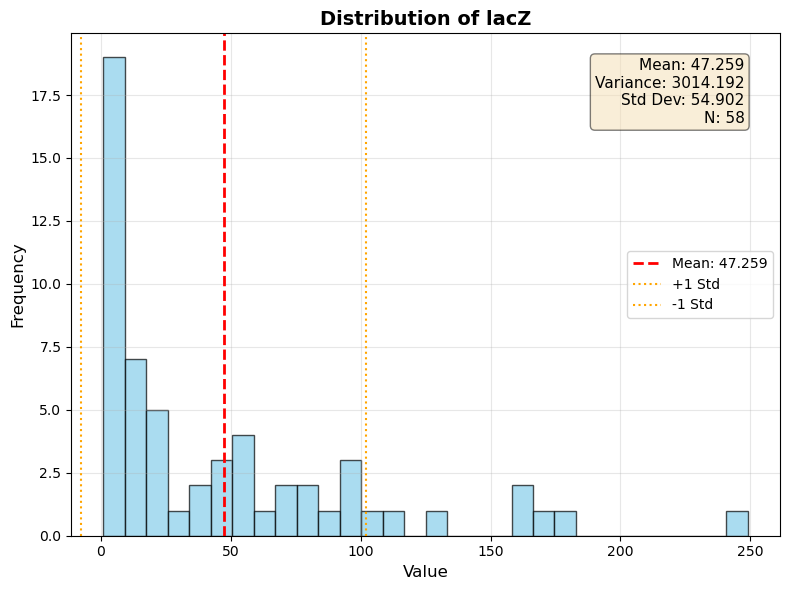

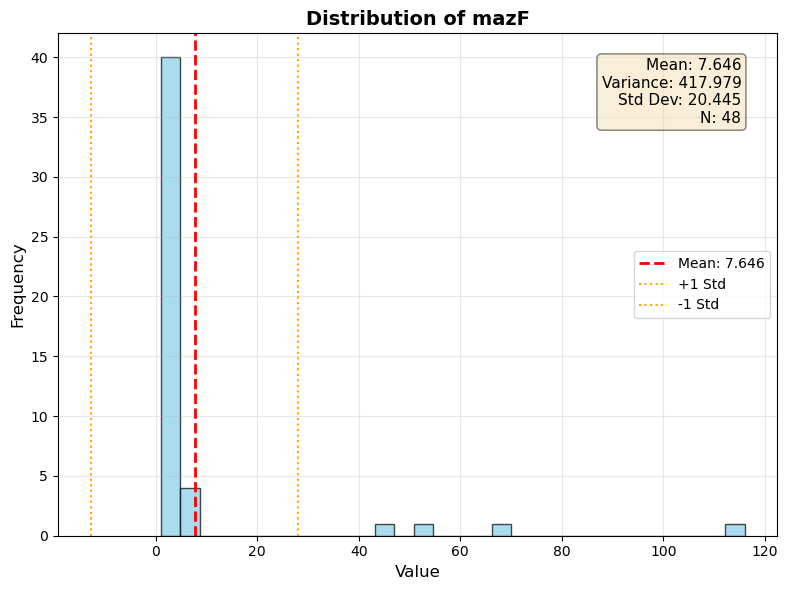

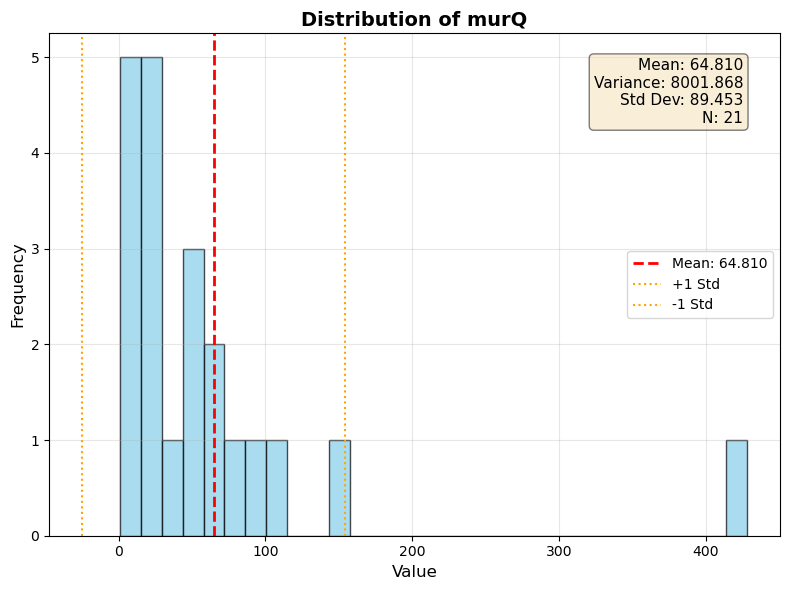

In [24]:
plot_gapExperssion_stats(results=results)